<div style="background: linear-gradient(135deg, #1e1b4b, #312e81); color:white; padding:25px; border-radius:10px; 
            text-align:center; font-family:'Segoe UI', sans-serif;">

  <h1 style="margin-bottom:8px;"> WikiArt Image Classification</h1>
  <h3 style="margin-top:0; font-style:italic; font-weight:normal; color:#a5b4fc;">
    Transfer Learning with EfficientNetB5
  </h3>

  <hr style="width:60%; border:1px solid #6366f1; margin:15px auto;">

  <p style="margin:5px 0; font-size:15px;">
    <b>Group Project</b> - Deep Learning (2025/2026)
  </p>
  <p style="margin:0; font-size:13px; color:#c7d2fe;">
    Master in Data Science and Advanced Analytics - Nova Information Management School
  </p>
</div>

<br>

<div style="background-color:#1e293b; color:#e0e7ff; padding:15px 20px; border-left:5px solid #6366f1; 
            border-radius:6px; font-family:'Segoe UI', sans-serif; font-size:14px;">

  <b>Notebook Description</b><br>
  Transfer learning approach using an EfficientNetB5 backbone pretrained on ImageNet, 
  fine-tuned for artist classification on the WikiArt dataset. 
  The model is evaluated using macro F1 score to account for class imbalance across the 23 artist categories.

</div>

<br>

**<h3>Table of Contents</h3>**
* [1. Environment Setup](#1-environment-setup)
* [2. Model Implementation](#2-model)
* [3. Model Evaluation](#3-eval)

<div id="1-environment-setup" style="background-color:#1e293b; padding:18px; border-radius:6px;">
  <h2 style="margin:0; color:#a5b4fc;">
    1. Setup
  </h2>
</div>

In [1]:
import os
import sys
import yaml
import tensorflow as tf
import keras
from keras import layers


# import utils functions auto-reload
%load_ext autoreload
%autoreload 2

sys.path.append(os.path.abspath('../src'))

from utils import *
from GPUGuard import GPUGuard

from tensorflow.keras.applications import EfficientNetB5

# Load config (relative to notebooks/)
with open('../config.yml', 'r') as f:
    config = yaml.safe_load(f)

SEED = config['seed']
set_seeds(SEED)

I0000 00:00:1776668779.509507  248868 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


<div id="2-model" style="background-color:#1e293b; padding:18px; border-radius:6px;">
  <h2 style="margin:0; color:#a5b4fc;">
    2. Model Implementation
  </h2>
</div>

In [2]:
IMG_SIZE = (512, 512)
BATCH_SIZE = 4
NUM_CLASSES = config['num_classes']
MAX_EPOCHS = config['max_epochs']

# Set paths (relative to notebooks/)
train_dir = config['paths']['train_dir']
val_dir   = config['paths']['val_dir']
test_dir  = config['paths']['test_dir']

# Load datasets
train_ds, val_ds, test_ds, class_names = load_datasets(
    train_dir, val_dir, test_dir,
    img_size=IMG_SIZE, batch_size=BATCH_SIZE
     )

# prefetch datasets for performance
autotune = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(buffer_size=autotune)
val_ds = val_ds.prefetch(buffer_size=autotune)
test_ds = test_ds.prefetch(buffer_size=autotune)

# compute class weights from training dataset
class_weights = class_weights(train_ds)

# callbacks
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_f1_macro",
        patience=5,
        restore_best_weights=True,
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_f1_macro",
        factor=0.5,
        patience=3,
        min_lr=1e-7,
        verbose=1,
    ),
    keras.callbacks.ModelCheckpoint(
        filepath=config['models']['efficientnetb5']['checkpoint'],
        monitor="val_f1_macro",
        save_best_only=True,
        verbose=1,
    ),
    GPUGuard(max_usage_ratio=0.95)
 ]

Found 9282 files belonging to 23 classes.


W0000 00:00:1776668781.722509  248868 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
W0000 00:00:1776668781.726230  248868 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
I0000 00:00:1776668781.832098  248868 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 4855 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 5060, pci bus id: 0000:2b:00.0, compute capability: 12.0a


Found 1980 files belonging to 23 classes.
Found 2012 files belonging to 23 classes.
Classes (23): ['Albrecht_Durer', 'Boris_Kustodiev', 'Camille_Pissarro', 'Childe_Hassam', 'Claude_Monet', 'Edgar_Degas', 'Eugene_Boudin', 'Gustave_Dore', 'Ilya_Repin', 'Ivan_Aivazovsky', 'Ivan_Shishkin', 'John_Singer_Sargent', 'Marc_Chagall', 'Martiros_Saryan', 'Nicholas_Roerich', 'Pablo_Picasso', 'Paul_Cezanne', 'Pierre_Auguste_Renoir', 'Pyotr_Konchalovsky', 'Raphael_Kirchner', 'Rembrandt', 'Salvador_Dali', 'Vincent_van_Gogh']


In [3]:
# --- Data Augmentation ---
data_augmentation = keras.Sequential([
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.05, fill_mode="nearest"),
        layers.RandomZoom(0.1),
        layers.RandomBrightness(0.1),
        layers.RandomContrast(0.1),
    ], name='data_augmentation')

# --- Build Model ---
base_model = EfficientNetB5(weights="imagenet", include_top=False, input_shape=(*IMG_SIZE, 3))
base_model.trainable = False  # freeze backbone for phase 1

inputs = keras.Input(shape=(*IMG_SIZE, 3))
x = data_augmentation(inputs)
x = base_model(x, training=False)     # training=False keeps BN layers in inference mode while frozen
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x) 
x = layers.Dense(512, activation="relu", kernel_regularizer=keras.regularizers.l2(0.001))(x)
x = layers.Dropout(0.5)(x)
x = layers.Dense(256, activation="relu")(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)

model = keras.Model(inputs, outputs, name="efficientnetb5_transfer")
model.summary()

Model: "efficientnetb5_transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 512, 512, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 512, 512, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb5 (Functional)     │ (None, 16, 16, 2048)   │    28,513,527 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 2048)           │         8,192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 23)             │         5,911 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,708,046 (113.33 MB)

 Trainable params: 1,190,423 (4.54 MB)

 Non-trainable params: 28,517,623 (108.79 MB)

In [4]:
model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=1e-4, 
        weight_decay=1e-4, 
        gradient_accumulation_steps=32
    ),
    loss="categorical_crossentropy", 
    metrics=["accuracy", keras.metrics.F1Score(average="macro", name="f1_macro")],
)

In [5]:
history_phase1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=MAX_EPOCHS,
    callbacks=callbacks,
    class_weight=class_weights
)

Epoch 1/100


I0000 00:00:1776668804.565027  248946 cuda_dnn.cc:461] Loaded cuDNN version 92000


2321/2321 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - accuracy: 0.0616 - f1_macro: 0.0555 - loss: 4.5606
Epoch 1: val_f1_macro improved from None to 0.27388, saving model to ../models/efficientnetb5_best.keras

Epoch 1: finished saving model to ../models/efficientnetb5_best.keras
2321/2321 ━━━━━━━━━━━━━━━━━━━━ 264s 108ms/step - accuracy: 0.0901 - f1_macro: 0.0854 - loss: 4.2506 - val_accuracy: 0.3040 - val_f1_macro: 0.2739 - val_loss: 3.2540 - learning_rate: 1.0000e-04
Epoch 2/100
2320/2321 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - accuracy: 0.1593 - f1_macro: 0.1500 - loss: 3.7562
Epoch 2: val_f1_macro improved from 0.27388 to 0.36340, saving model to ../models/efficientnetb5_best.keras

Epoch 2: finished saving model to ../models/efficientnetb5_best.keras
2321/2321 ━━━━━━━━━━━━━━━━━━━━ 241s 104ms/step - accuracy: 0.1824 - f1_macro: 0.1736 - loss: 3.6418 - val_accuracy: 0.4015 - val_f1_macro: 0.3634 - val_loss: 2.9164 - learning_rate: 1.0000e-04
Epoch 3/100
2320/2321 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/st

In [6]:
phase_2_callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath=config['models']['efficientnetb5']['checkpoint'],
        monitor="val_f1_macro",
        save_best_only=True,
        verbose=1,
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_f1_macro", 
        mode="max", 
        patience=10, 
        restore_best_weights=True
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_f1_macro", 
        mode="max", 
        factor=0.5, 
        patience=4 
    ),
    GPUGuard(max_usage_ratio=0.95)
]

In [7]:
# --- Phase 2: Fine-tuning ---

# Unfreeze the last ~50 layers of EfficientNetB5.
# EfficientNet blocks are deeper than ResNet, so more layers must be unfrozen
base_model.trainable = True
for layer in base_model.layers[:-50]:
    layer.trainable = False

# Very low LR to avoid disrupting pretrained weights
model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=1e-5,
        weight_decay=1e-5,
        gradient_accumulation_steps=32
        ),
    loss="categorical_crossentropy",
    metrics=["accuracy", keras.metrics.F1Score(average="macro", name="f1_macro")],
)

history_phase2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=MAX_EPOCHS,
    callbacks=phase_2_callbacks,
    class_weight=class_weights,
)

Epoch 1/100


E0000 00:00:1776682921.991568  248868 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/efficientnetb5_transfer_1/efficientnetb5_1/block1b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


2320/2321 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - accuracy: 0.5122 - f1_macro: 0.5032 - loss: 2.2131
Epoch 1: val_f1_macro improved from None to 0.59284, saving model to ../models/efficientnetb5_best.keras

Epoch 1: finished saving model to ../models/efficientnetb5_best.keras
2321/2321 ━━━━━━━━━━━━━━━━━━━━ 277s 113ms/step - accuracy: 0.5220 - f1_macro: 0.5193 - loss: 2.1565 - val_accuracy: 0.6101 - val_f1_macro: 0.5928 - val_loss: 1.8888 - learning_rate: 1.0000e-05
Epoch 2/100
2320/2321 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - accuracy: 0.5489 - f1_macro: 0.5445 - loss: 2.0405
Epoch 2: val_f1_macro improved from 0.59284 to 0.60177, saving model to ../models/efficientnetb5_best.keras

Epoch 2: finished saving model to ../models/efficientnetb5_best.keras
2321/2321 ━━━━━━━━━━━━━━━━━━━━ 259s 112ms/step - accuracy: 0.5543 - f1_macro: 0.5517 - loss: 2.0212 - val_accuracy: 0.6202 - val_f1_macro: 0.6018 - val_loss: 1.8427 - learning_rate: 1.0000e-05
Epoch 3/100
2320/2321 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/st

In [8]:
test_loss, test_accuracy, test_f1, _ , _ ,_  = predict_tta(model, test_ds)
print(f"TTA Results - Loss: {test_loss:.4f} | Accuracy: {test_accuracy:.4f} | F1: {test_f1:.4f}")


TTA Results - Loss: 1.3953 | Accuracy: 0.7758 | F1: 0.7589
TTA Results - Loss: 1.3953 | Accuracy: 0.7758 | F1: 0.7589


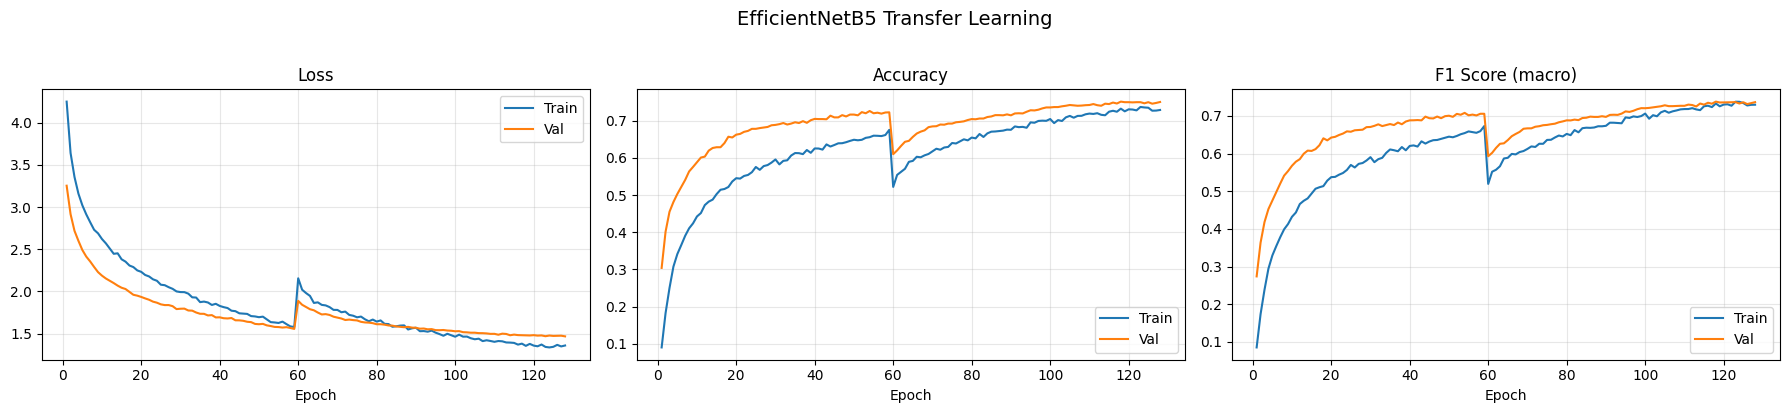

Best epoch (lowest val_loss): 128
  Val Loss: 1.4683
  Val Acc:  0.7505
  Val F1:   0.7363


In [9]:
plot_learning_curves([history_phase1, history_phase2], title="EfficientNetB5 Transfer Learning")

<div id="3-eval" style="background-color:#1e293b; padding:18px; border-radius:6px;">
  <h2 style="margin:0; color:#a5b4fc;">
    3. Model Evaluation
  </h2>
</div>


  EfficientNetB5 Transfer Learning - Test Evaluation
  Test Loss:     1.3953
  Test Accuracy: 0.7490
  Test F1 Macro: 0.7381

Classification Report:
                       precision    recall  f1-score   support

       Albrecht_Durer       0.84      0.83      0.83        87
      Boris_Kustodiev       0.63      0.58      0.60        67
     Camille_Pissarro       0.61      0.73      0.67        93
        Childe_Hassam       0.74      0.67      0.70        58
         Claude_Monet       0.88      0.61      0.72       141
          Edgar_Degas       0.70      0.77      0.74        65
        Eugene_Boudin       0.61      0.92      0.73        59
         Gustave_Dore       0.92      0.97      0.95        80
           Ilya_Repin       0.51      0.66      0.58        58
      Ivan_Aivazovsky       0.81      0.93      0.87        61
        Ivan_Shishkin       0.62      0.78      0.69        55
  John_Singer_Sargent       0.61      0.81      0.69        83
         Marc_Chagall       0.

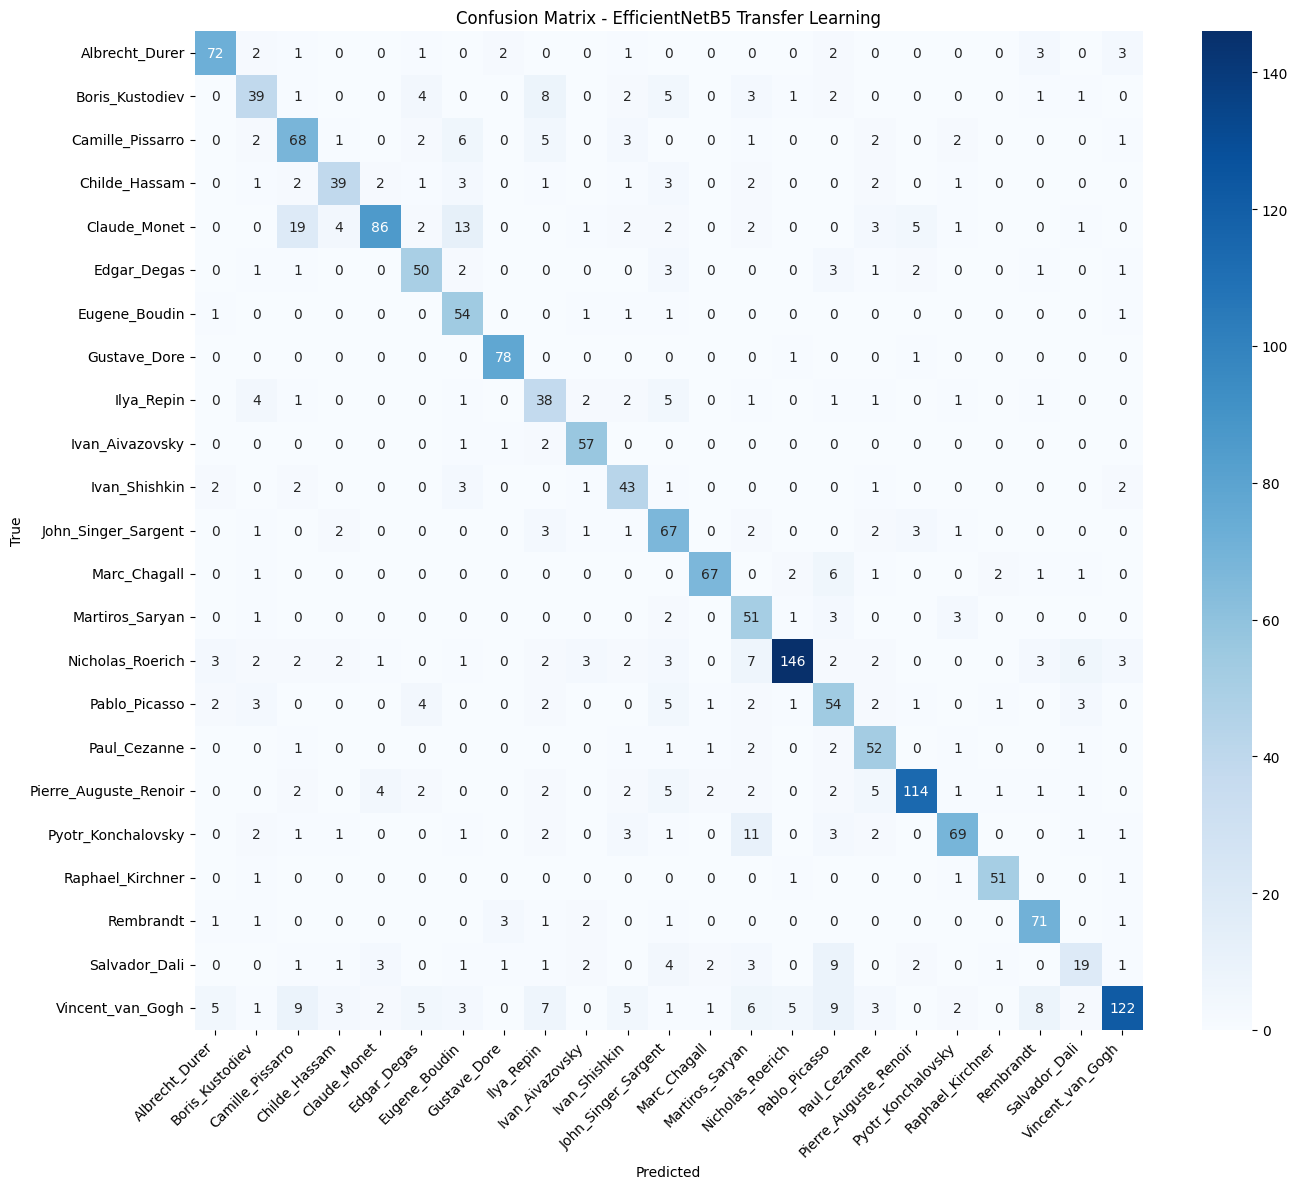

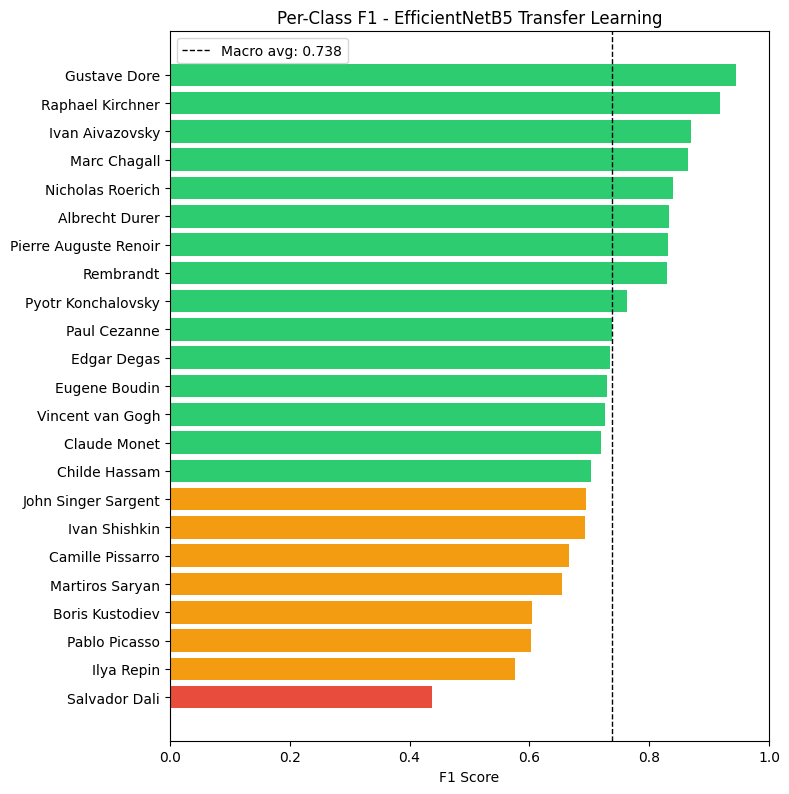

In [10]:
metrics_efficientnet = evaluate_model(model, test_ds, class_names, "EfficientNetB5 Transfer Learning")

In [11]:
save_history([history_phase1, history_phase2], config['models']['efficientnetb5']['history'])

History saved to ../models/efficientnetb5_history.json
